In [1]:
pip install --user xgboost lightgbm catboost

In [2]:
# Importing libs 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Loading CSV

In [5]:
df1 = pd.read_csv('station_54026.csv')
df2 = pd.read_csv('station_50727.csv')
df3 = pd.read_csv('station_54316.csv')

df1['Station'] = '54026'
df2['Station'] = '50727'
df3['Station'] = '54316'

df = pd.concat([df1, df2, df3], ignore_index=True)

In [6]:
# pre processing

In [7]:
# 1. Basic cleaning
df.columns = df.columns.str.strip().str.lower()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.drop_duplicates().reset_index(drop=True)

# 2. Handle datetime columns
possible_dt_cols = ['datetime', 'date', 'timestamp', 'time']
datetime_col = next((col for col in possible_dt_cols if col in df.columns), None)

if datetime_col:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
    df = df.sort_values(datetime_col).reset_index(drop=True)

# 3. Drop columns with too many missing values
threshold = 0.5  # drop columns with >50% NaNs
df = df.loc[:, df.isnull().mean() < threshold]

# 4. Handle missing values manually
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

# Fill numeric columns with median
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Fill categorical columns with mode or 'Unknown'
for col in cat_cols:
    mode_val = df[col].mode()
    df[col] = df[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

# 5. Outlier capping (IQR method)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

# 6. Scale numeric features
if len(num_cols) > 0:
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

# 7. Final cleanup
df = df.dropna().reset_index(drop=True)

print("Data Preprocessing Complete!")
print("Final Shape:", df.shape)
print("Numeric columns scaled:", len(num_cols))
print("Categorical columns:", cat_cols.tolist())


Data Preprocessing Complete!
Final Shape: (105189, 16)
Numeric columns scaled: 15
Categorical columns: ['station']


In [8]:
df.info()
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105189 entries, 0 to 105188
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   station_id_c   105189 non-null  float64
 1   lat            105189 non-null  float64
 2   lon            105189 non-null  float64
 3   alti           105189 non-null  float64
 4   year           105189 non-null  float64
 5   mon            105189 non-null  float64
 6   day            105189 non-null  float64
 7   hour           105189 non-null  float64
 8   prs            105189 non-null  float64
 9   tem            105189 non-null  float64
 10  vis_hor_10mi   105189 non-null  float64
 11  win_s_avg_2mi  105189 non-null  float64
 12  win_d_avg_2mi  105189 non-null  float64
 13  win_s_max      105189 non-null  float64
 14  win_d_s_max    105189 non-null  float64
 15  station        105189 non-null  object 
dtypes: float64(15), object(1)
memory usage: 12.8+ MB
station_id_c     0
lat   

,station_id_c,lat,lon,alti,year,mon,day,hour,prs,tem,vis_hor_10mi,win_s_avg_2mi,win_d_avg_2mi,win_s_max,win_d_s_max
count,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05,1.051890e+05
mean,7.954588e-16,2.680350e-15,-3.112665e-14,-3.728713e-16,-6.052404e-16,1.783298e-16,5.349893e-17,-6.532003e-17,4.145897e-15,-6.484718e-18,1.037555e-16,-8.646291e-18,-1.059171e-16,7.565505e-17,-6.917033e-17
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.410438e+00,-1.252504e+00,-1.265285e+00,-1.275531e+00,-1.340410e+00,-2.011416e+00,-1.673776e+00,-1.661414e+00,-1.846934e+00,-3.078249e+00,-2.597280e+00,-1.437633e+00,-2.051186e+00,-1.741620e+00,-2.367775e+00
25%,-1.410438e+00,-1.252504e+00,-1.265285e+00,-1.275531e+00,-1.340410e+00,-5.954009e-01,-8.783348e-01,-7.946140e-01,-1.009269e+00,-7.541952e-01,-6.363215e-01,-7.861183e-01,-6.731046e-01,-7.960938e-01,-6.925056e-01
50%,6.161729e-01,5.753056e-02,8.558356e-02,1.087574e-01,-4.462166e-01,1.126065e-01,3.074068e-02,7.218594e-02,-8.699181e-02,1.248165e-01,6.709845e-01,-2.649065e-01,1.380446e-01,-2.642352e-01,2.030788e-01
75%,7.943231e-01,1.194941e+00,1.179733e+00,1.166704e+00,4.479763e-01,4.666102e-01,8.261818e-01,9.389858e-01,1.018613e+00,8.173712e-01,6.709845e-01,5.820626e-01,6.439225e-01,6.221958e-01,8.247198e-01
max,7.943231e-01,1.194941e+00,1.179733e+00,1.166704e+00,1.342169e+00,1.882625e+00,1.735257e+00,1.661319e+00,1.954993e+00,2.335664e+00,2.631944e+00,2.634334e+00,2.619463e+00,2.749630e+00,3.100558e+00


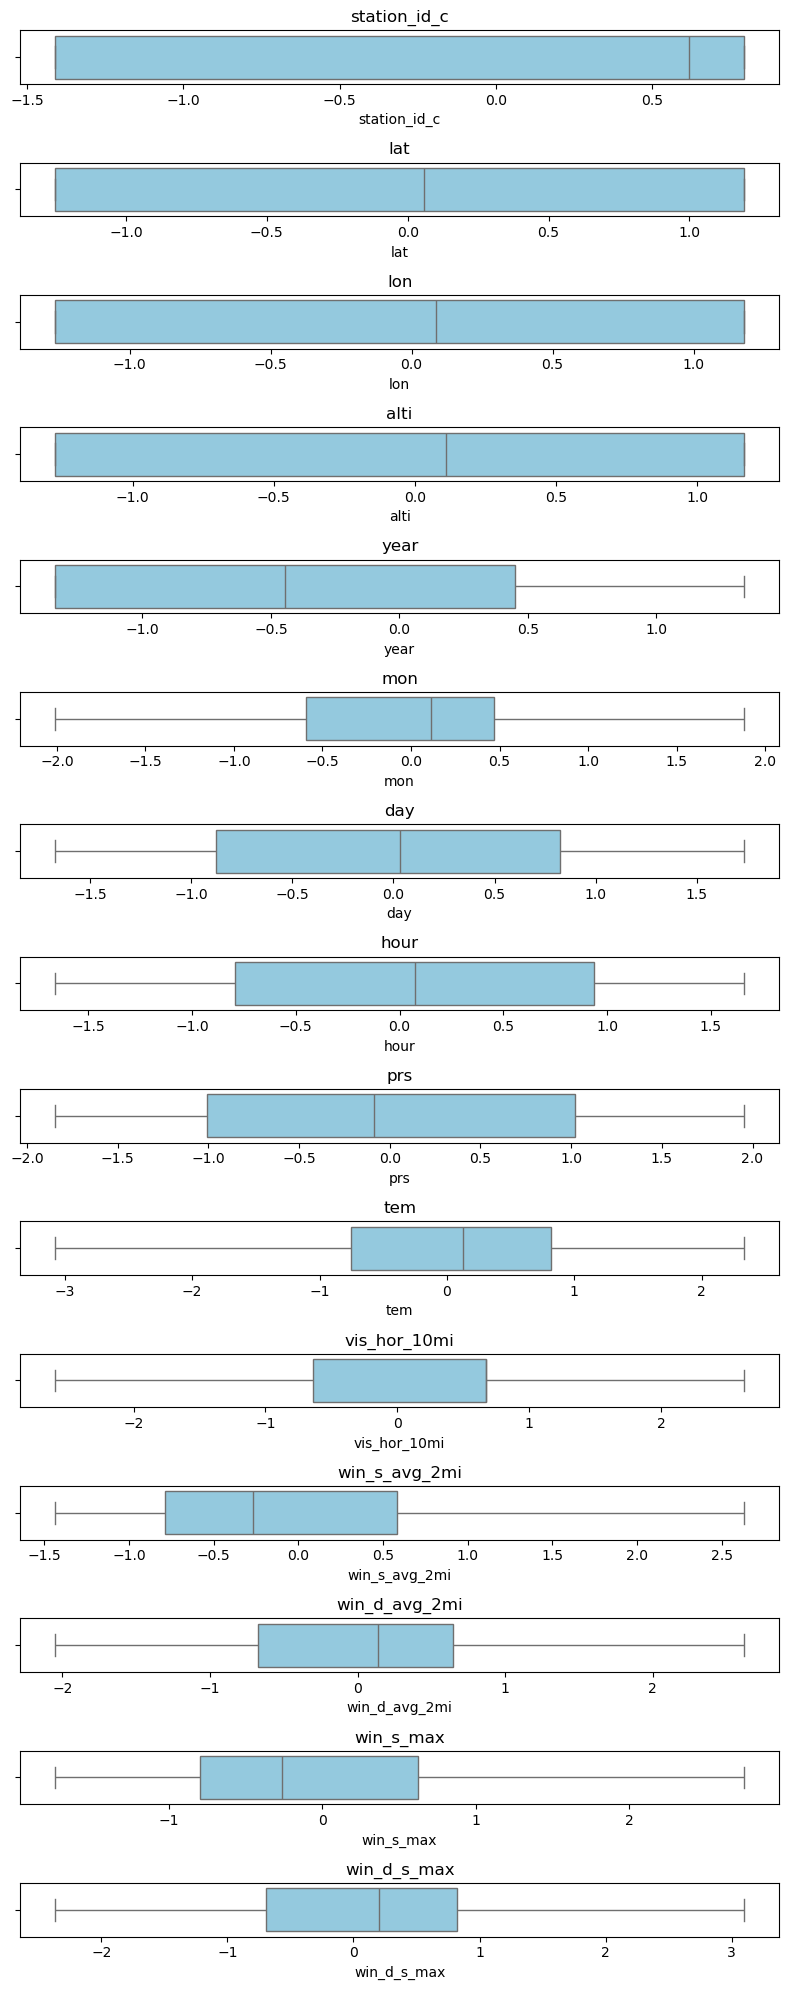

In [9]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(8, 20))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axs[i], color='skyblue')
    axs[i].set_title(col)
plt.tight_layout()
plt.show()

In [10]:
# Removing outliers

In [11]:
# --- Safe Outlier Removal (IQR method) ---
outlier_cols = ['TEM', 'PRS', 'WIN_S_Avg_2mi', 'WIN_S_Max']

# convert to lowercase for consistency
df.columns = df.columns.str.strip().str.lower()

# loop safely through only the columns that exist in df
for col in [c.lower() for c in outlier_cols if c.lower() in df.columns]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = len(df)

    print(f"Removed {before - after} outliers from '{col}'")

print("Outlier cleaning completed! Final shape:", df.shape)


Removed 0 outliers from 'tem'
Removed 0 outliers from 'prs'
Removed 0 outliers from 'win_s_avg_2mi'
Removed 0 outliers from 'win_s_max'
Outlier cleaning completed! Final shape: (105189, 16)


In [12]:
# Correlation Analysis

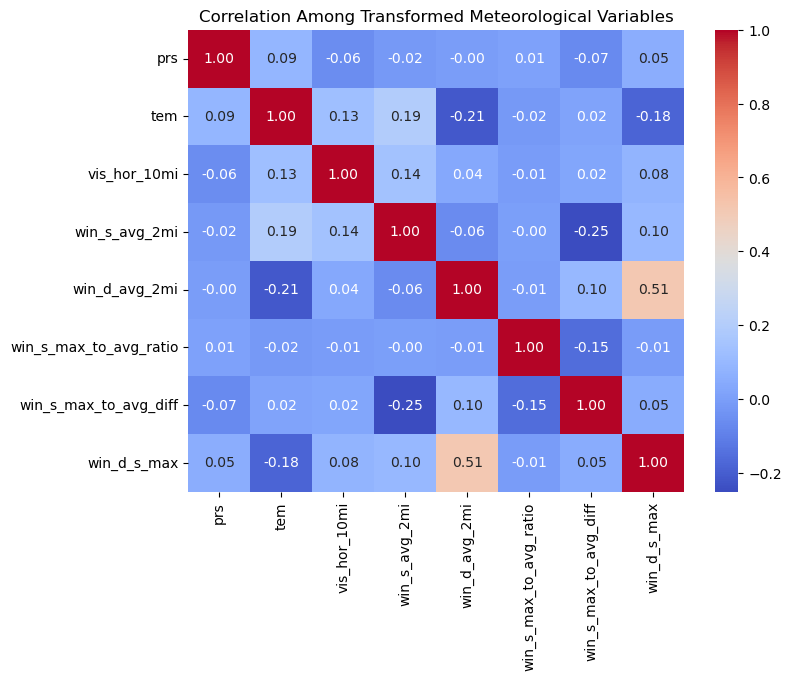

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure column names are consistent
df.columns = df.columns.str.strip().str.lower()

# Derived features (safe division to avoid zero/NaN)
if 'win_s_max' in df.columns and 'win_s_avg_2mi' in df.columns:
    df['win_s_max_to_avg_ratio'] = df['win_s_max'] / (df['win_s_avg_2mi'] + 1e-5)
    df['win_s_max_to_avg_diff'] = df['win_s_max'] - df['win_s_avg_2mi']
else:
    raise KeyError("Required columns 'win_s_max' or 'win_s_avg_2mi' not found in DataFrame.")

# Columns for correlation heatmap (only those that exist)
cols_to_corr = [
    'prs', 'tem', 'vis_hor_10mi',
    'win_s_avg_2mi', 'win_d_avg_2mi',
    'win_s_max_to_avg_ratio', 'win_s_max_to_avg_diff', 'win_d_s_max'
]
available_cols = [c for c in cols_to_corr if c in df.columns]

# Compute correlation safely
corr = df[available_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Among Transformed Meteorological Variables')
plt.show()

In [14]:
# Visualizing Distributions of data

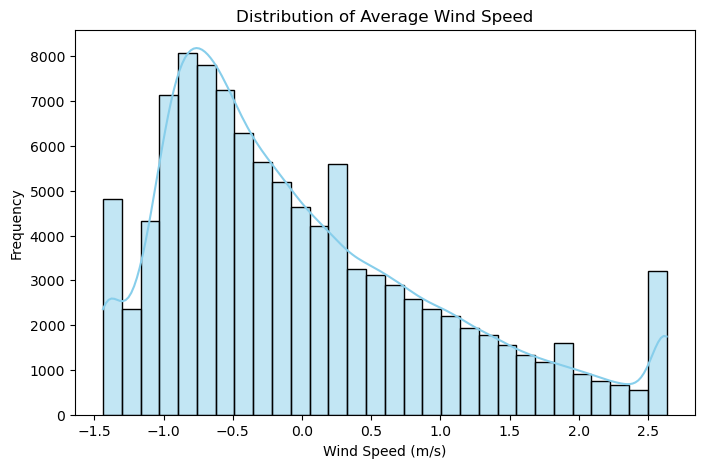

In [15]:
# Visualize distributions of raw data
plt.figure(figsize=(8,5))
sns.histplot(df['win_s_avg_2mi'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Average Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Separating features and target variables

In [17]:
y = df['win_s_avg_2mi']
X = df.drop(columns=['WIN_S_Avg_2mi', 'datetime'], errors='ignore')

In [18]:
# Resample before feature engineering
sample_size = 35000
if len(df) > sample_size:
    df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)


In [19]:
# Feature Engineering

In [20]:
import numpy as np
import pandas as pd

# --- Clean column names ---
df.columns = df.columns.str.strip().str.lower()

# --- Auto-detect or create datetime ---
possible_dt_cols = ['datetime', 'date', 'time', 'timestamp']
datetime_col = next((col for col in possible_dt_cols if col in df.columns), None)

if datetime_col:
    df['datetime'] = pd.to_datetime(df[datetime_col], errors='coerce')
elif all(col in df.columns for col in ['year', 'mon', 'day', 'hour']):
    df['datetime'] = pd.to_datetime(
        dict(year=df['year'], month=df['mon'], day=df['day'], hour=df['hour']),
        errors='coerce'
    )
elif all(col in df.columns for col in ['year', 'month', 'day', 'hour']):
    df['datetime'] = pd.to_datetime(
        dict(year=df['year'], month=df['month'], day=df['day'], hour=df['hour']),
        errors='coerce'
    )
else:
    raise KeyError(f"Could not create datetime. Available columns: {df.columns.tolist()}")

# --- Sort and clean ---
df = df.sort_values('datetime').reset_index(drop=True)

# --- Time-based features ---
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# --- Cyclic encodings ---
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# --- Lag features (shifted to avoid leakage) ---
for lag in [1, 3, 6, 12]:
    df[f'win_s_avg_2mi_lag{lag}'] = df['win_s_avg_2mi'].shift(lag)

# --- Safe rolling features (use shifted target to prevent leakage) ---
for lag in [1, 3, 6, 12]:
    df[f'win_s_avg_2mi_rollmean{lag}'] = (
        df['win_s_avg_2mi'].shift(1).rolling(window=lag, min_periods=1).mean()
    )
    df[f'win_s_avg_2mi_rollstd{lag}'] = (
        df['win_s_avg_2mi'].shift(1).rolling(window=lag, min_periods=1).std()
    )

# --- Wind decomposition (no target leakage) ---
df['wind_u'] = df['win_s_avg_2mi_lag1'] * np.cos(np.deg2rad(df['win_d_avg_2mi']))
df['wind_v'] = df['win_s_avg_2mi_lag1'] * np.sin(np.deg2rad(df['win_d_avg_2mi']))

# --- Temperature-based transformations ---
df['temp_squared'] = df['tem'] ** 2
df['temp_cubed'] = df['tem'] ** 3

# --- Fill missing values instead of dropping (no warnings) ---
df = df.bfill().ffill()

# --- Feature interactions ---
df['prs_temp_ratio'] = df['prs'] / (df['tem'] + 273.15)
df['vis_temp_interaction'] = df['vis_hor_10mi'] * df['tem']
df['prs_temp_interaction'] = df['prs'] * df['tem']
df['win_s_max_to_avg_ratio'] = df['win_s_max'] / (df['win_s_avg_2mi'] + 1e-5)
df['win_s_max_to_avg_diff'] = df['win_s_max'] - df['win_s_avg_2mi']
df['temp_squared'] = df['tem'] ** 2
df['temp_cubed'] = df['tem'] ** 3

# --- Handle NaN values from lag/rolling safely (no warnings) ---
df = df.bfill().ffill()

# --- Drop non-numeric / redundant columns ---
cols_to_drop = []
if 'station' in df.columns:
    cols_to_drop.append('station')
if 'datetime' in df.columns:
    cols_to_drop.append('datetime')

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# --- Final cleanup: ensure only numeric columns remain for modeling ---
df = df.select_dtypes(include=['number'])

print("Feature Engineering Complete! Final Shape:", df.shape)
print("Columns retained:", df.columns.tolist())


Feature Engineering Complete! Final Shape: (35000, 45)
Columns retained: ['station_id_c', 'lat', 'lon', 'alti', 'year', 'mon', 'day', 'hour', 'prs', 'tem', 'vis_hor_10mi', 'win_s_avg_2mi', 'win_d_avg_2mi', 'win_s_max', 'win_d_s_max', 'win_s_max_to_avg_ratio', 'win_s_max_to_avg_diff', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'win_s_avg_2mi_lag1', 'win_s_avg_2mi_lag3', 'win_s_avg_2mi_lag6', 'win_s_avg_2mi_lag12', 'win_s_avg_2mi_rollmean1', 'win_s_avg_2mi_rollstd1', 'win_s_avg_2mi_rollmean3', 'win_s_avg_2mi_rollstd3', 'win_s_avg_2mi_rollmean6', 'win_s_avg_2mi_rollstd6', 'win_s_avg_2mi_rollmean12', 'win_s_avg_2mi_rollstd12', 'wind_u', 'wind_v', 'temp_squared', 'temp_cubed', 'prs_temp_ratio', 'vis_temp_interaction', 'prs_temp_interaction']


In [21]:
# Data Splitting

In [22]:
# Define target and features
target = 'win_s_avg_2mi'

# Separate features (X) and target (y)
X = df.drop(columns=[target])
y = df[target]

# Time-based split (keeps temporal order)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (28000, 44)
Testing set: (7000, 44)


In [23]:
# Train - Validation Split

In [24]:
val_split = int(len(X_train) * 0.8)
X_val, y_val = X_train.iloc[val_split:], y_train.iloc[val_split:]
X_train = X_train.iloc[:val_split]
y_train = y_train.iloc[:val_split]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (22400, 44) Val: (5600, 44) Test: (7000, 44)


In [25]:
# Random Forest Regressor

In [27]:
# Keep only numeric columns
from sklearn.ensemble import RandomForestRegressor
X_train = X_train.select_dtypes(include=['number']).copy()
X_val = X_val.select_dtypes(include=['number']).copy()

# -------------------------------
#  Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=800,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_model.fit(X_train, y_train)
print("\n Random Forest training completed")
print("OOB R² Score:", rf_model.oob_score_)


#  Validation performance

y_pred = rf_model.predict(X_val)
r2 = r2_score(y_val, y_pred)

print(f"Validation R² Score: {r2:.6f}")
print(f"Difference (OOB - Val): {abs(rf_model.oob_score_ - r2):.6f}")



 Random Forest training completed
OOB R² Score: 0.9609792212496844
Validation R² Score: 0.960128
Difference (OOB - Val): 0.000851


In [ ]:
# evaluation of metrics

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_val_pred = rf_model.predict(X_val)

# Evaluation Metrics
r2 = r2_score(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"R² Score: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")


R² Score: 0.960128
MAE: 0.134693
RMSE: 0.198412


In [ ]:
# visualization

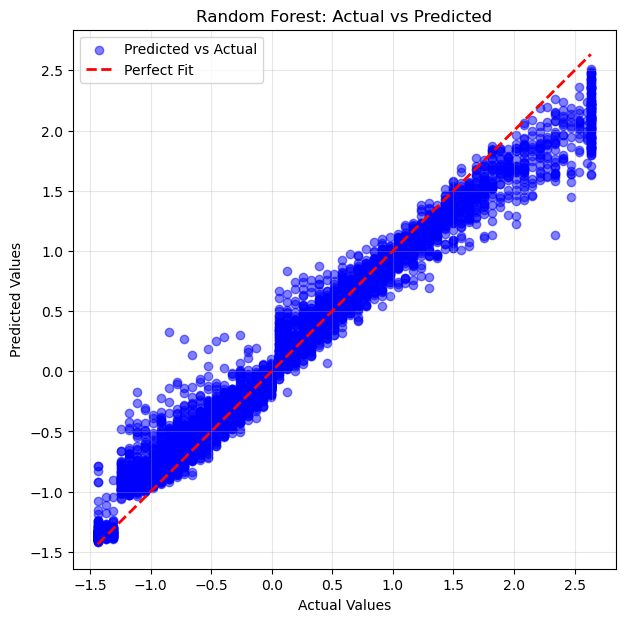

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_val, y_val_pred, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cross-Validation

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Use numeric columns only
X_train = X_train.select_dtypes(include=['number']).copy()
y_train = y_train.copy()

# Define model
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Define K-Fold Cross Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation (R² as scoring)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

print("Cross-Validation R² scores:", np.round(cv_scores, 6))
print("Mean R²:", np.mean(cv_scores).round(6))
print("Std. Deviation:", np.std(cv_scores).round(6))


Cross-Validation R² scores: [0.959819 0.958252 0.95662  0.954997 0.960887]
Mean R²: 0.958115
Std. Deviation: 0.002124


In [31]:
# XGBoost Regressor 

In [ ]:
# Training XGBoost 

In [32]:
from xgboost import XGBRegressor

# Initialize and train model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")


XGBoost training completed.


In [33]:
# Evaluation Metrics 

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = xgb_model.predict(X_val)

r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"R² Score: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

R² Score: 0.999417
MAE: 0.013245
RMSE: 0.023987


In [35]:
# Visualization

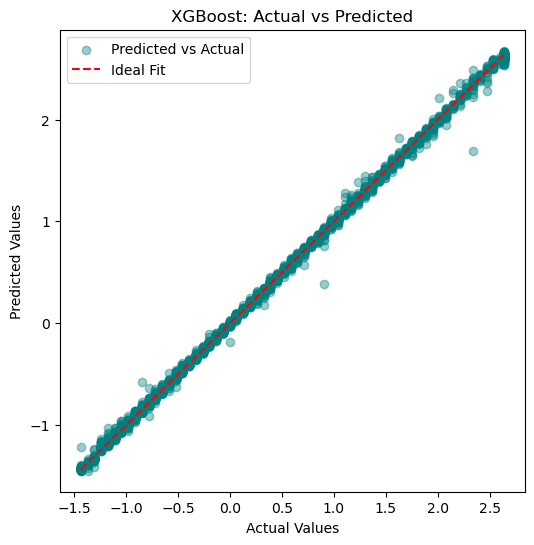

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.4, color='teal', label='Predicted vs Actual')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.show()


In [ ]:
# Cross Validation

In [38]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² scores:", np.round(cv_scores, 6))
print("Mean R²:", np.mean(cv_scores))
print("Std. Deviation:", np.std(cv_scores))


Cross-Validation R² scores: [0.999365 0.999389 0.999337 0.999426 0.999082]
Mean R²: 0.9993198771740633
Std. Deviation: 0.00012254142771858878


In [ ]:
# LighGBM

In [ ]:
# Model Training

In [39]:
from lightgbm import LGBMRegressor

# Initialize and train model
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
print(" LightGBM training completed.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5518
[LightGBM] [Info] Number of data points in the train set: 22400, number of used features: 31
[LightGBM] [Info] Start training from score -0.002634
 LightGBM training completed.


In [ ]:
# Evaluation Metrics

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = lgb_model.predict(X_val)

r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"R² Score: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")


R² Score: 0.999137
MAE: 0.018254
RMSE: 0.029187


In [ ]:
# Visualization

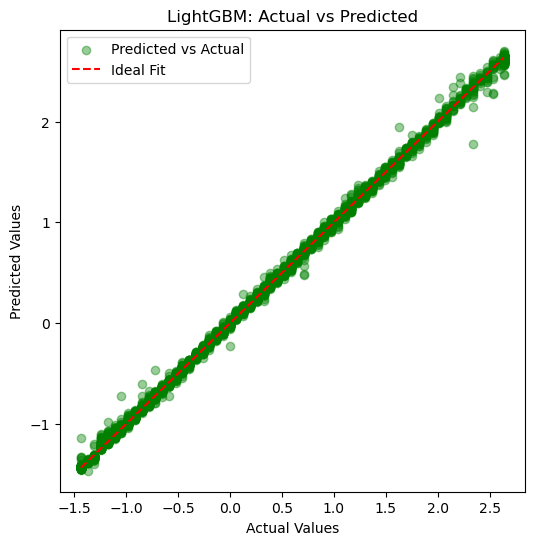

In [41]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.4, color='green', label='Predicted vs Actual')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LightGBM: Actual vs Predicted")
plt.legend()
plt.show()


In [ ]:
# Cross Validation

In [42]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgb_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² scores:", np.round(cv_scores, 6))
print("Mean R²:", np.mean(cv_scores))
print("Std. Deviation:", np.std(cv_scores))

Cross-Validation R² scores: [0.999231 0.99911  0.999041 0.999235 0.998851]
Mean R²: 0.9990936129269052
Std. Deviation: 0.00014205240456680805


In [ ]:
# CatBoost Regressor

In [ ]:
# Model Training

In [43]:
from catboost import CatBoostRegressor

# Initialize and train CatBoost model
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    loss_function='RMSE',
    verbose=100
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
print("CatBoost training completed.")


0:	learn: 0.9538356	test: 0.9487511	best: 0.9487511 (0)	total: 174ms	remaining: 1m 26s
100:	learn: 0.0468846	test: 0.0483315	best: 0.0483315 (100)	total: 2.84s	remaining: 11.2s
200:	learn: 0.0296115	test: 0.0323201	best: 0.0323201 (200)	total: 6.7s	remaining: 9.97s
300:	learn: 0.0223829	test: 0.0263524	best: 0.0263456 (297)	total: 10.6s	remaining: 7.04s
400:	learn: 0.0178409	test: 0.0226209	best: 0.0226209 (400)	total: 14.7s	remaining: 3.62s
499:	learn: 0.0150034	test: 0.0204972	best: 0.0204972 (499)	total: 18.7s	remaining: 0us

bestTest = 0.02049721862
bestIteration = 499

CatBoost training completed.


In [ ]:
# Evaluation Metrics

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = cat_model.predict(X_val)

r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"R² Score: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

R² Score: 0.999574
MAE: 0.011877
RMSE: 0.020497


In [ ]:
# Visualization

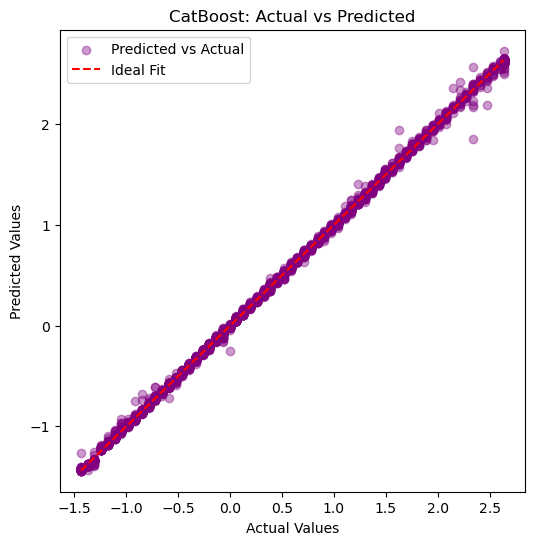

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.4, color='purple', label='Predicted vs Actual')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("CatBoost: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Cross Validation

In [46]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R² scores:", np.round(cv_scores, 6))
print("Mean R²:", np.mean(cv_scores))
print("Std. Deviation:", np.std(cv_scores))

Cross-Validation R² scores: [0.999582 0.999594 0.999455 0.99953  0.999278]
Mean R²: 0.9994877367296757
Std. Deviation: 0.00011570797432528902


Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5518
[LightGBM] [Info] Number of data points in the train set: 22400, number of used features: 31
[LightGBM] [Info] Start training from score -0.002634
Training CatBoost...

Model Performance Summary:
           Model        R²       MAE      RMSE  CV Mean R²    CV Std
0       CatBoost  0.999574  0.011877  0.020497    0.999488  0.000116
1        XGBoost  0.999417  0.013245  0.023987    0.999320  0.000123
2       LightGBM  0.999137  0.018254  0.029187    0.999094  0.000142
3  Random Forest  0.960128  0.134693  0.198412    0.957977  0.001980


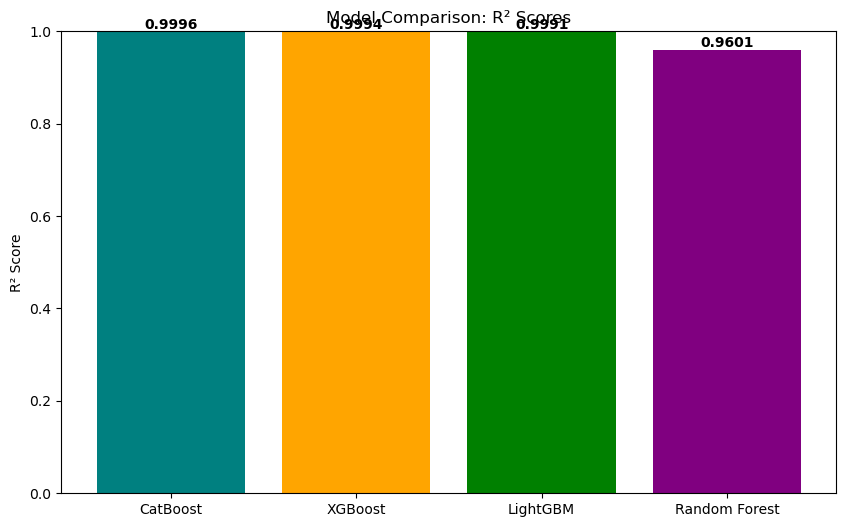

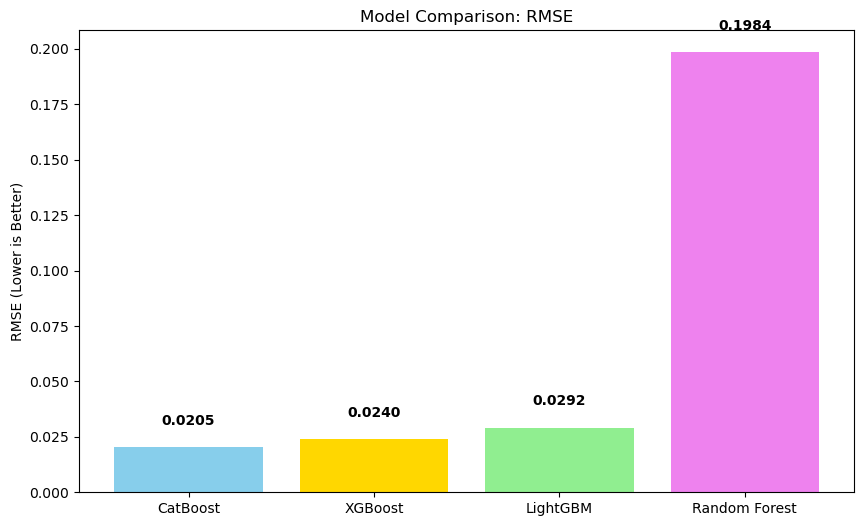

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Define all models ---
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=800, max_depth=20, min_samples_split=4,
        min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, random_seed=42, verbose=False
    )
}

# --- Cross-validation setup ---
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Store results ---
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Metrics
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    # Cross-validation (R²)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2', n_jobs=-1)
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    
    results.append({
        "Model": name,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "CV Mean R²": cv_mean,
        "CV Std": cv_std
    })

# --- Summary DataFrame ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)
print("\nModel Performance Summary:")
print(results_df)

# --- Visualization ---
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["R²"], color=['teal','orange','green','purple'])
plt.title("Model Comparison: R² Scores")
plt.ylabel("R² Score")
plt.ylim(0, 1)
for i, v in enumerate(results_df["R²"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# --- Compare RMSE visually ---
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["RMSE"], color=['skyblue','gold','lightgreen','violet'])
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE (Lower is Better)")
for i, v in enumerate(results_df["RMSE"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()
